# Settings

In [1]:
options(scipen=999)
pacman::p_load(dplyr, stringr, data.table, tidyr, plyr,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce)


## Directories

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

## Variables

In [3]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

In [21]:
# REMOVE acinar cells
# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Immune, Endothelial, Stromal)


# Permutation test

## Observations

In [35]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [36]:
# Split LR pairs
LR.data.ND = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[1], ]
LR.data.AAB = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[2], ]
LR.data.ETD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[3], ]
LR.data.LTD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[4], ]
nrow(LR.data.consensus.sig.thresh)
# Print stats
message("LR pairs in ND: ", nrow(LR.data.ND))
message("LR pairs in AAB : ", nrow(LR.data.AAB))
message("LR pairs in Early T1D: ", nrow(LR.data.ETD))
message("LR pairs in Late T1D: ", nrow(LR.data.LTD))

[1] 39479

LR pairs in ND: 12143

LR pairs in AAB : 12280

LR pairs in Early T1D: 9561

LR pairs in Late T1D: 5495



In [37]:
head(LR.data.consensus.sig.thresh, n=1)

,ligand,source,target,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,⋯,FDR,interaction.id,compartment.source,compartment.target,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,ADCYAP1R1,0.00006164112,0.0001,ADCYAP1_ADCYAP1R1,ADCYAP1 - ADCYAP1R1,PACAP,Secreted Signaling,⋯,0.000153715,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,Endocrine,Stromal,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [38]:
condition.sizes = c(nrow(LR.data.ND), nrow(LR.data.AAB), nrow(LR.data.ETD), nrow(LR.data.LTD))
condition.sizes

condition.size_1 = c(condition.sizes[2], condition.sizes[3], condition.sizes[4])
condition.size_2 = c(condition.sizes[1], condition.sizes[1], condition.sizes[1])

[1] 12143 12280  9561  5495

In [39]:
# Aggregate interactions
LR.ND = aggregate(LR.data.ND$prob, by=list(condition=LR.data.ND$condition),FUN=sum)
colnames(LR.ND)[2] = "IS"
LR.AAB = aggregate(LR.data.AAB$prob, by=list(condition=LR.data.AAB$condition),FUN=sum)
colnames(LR.AAB)[2] = "IS"
LR.ETD = aggregate(LR.data.ETD$prob, by=list(condition=LR.data.ETD$condition),FUN=sum)
colnames(LR.ETD)[2] = "IS"
LR.LTD = aggregate(LR.data.LTD$prob, by=list(condition=LR.data.LTD$condition),FUN=sum)
colnames(LR.LTD)[2] = "IS"
stat.data = rbind(LR.ND, LR.AAB, LR.ETD, LR.LTD)
stat.data$condition = factor(stat.data$condition, levels = rev(condition.ls))
# Count interactions
Interaction.number = as.data.frame(table(LR.data.consensus.sig.thresh$condition))
colnames(Interaction.number)[1] = "condition"
Interaction.number$condition = factor(Interaction.number$condition, levels = rev(condition.ls))
# Merge
stat.data = merge(stat.data, Interaction.number, by = "condition")
stat.data$average.IS = stat.data$IS/stat.data$Freq

In [40]:
diff.obs = list()
abs.diff.obs = list()
count.diff.obs = list()
count.abs.diff.obs = list()
avg.diff.obs = list()
avg.abs.diff.obs = list()

for (i in seq_along(Contrast_1)){
    # Subset to target cell
    LR.data.use <- LR.data.consensus.sig.thresh
    # Subset for the contrast
    contrast = c(Contrast_1[i], Contrast_2[i])
    message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
    LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
    LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
    message("Distribution of interactions in contrast: \n",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Replace NA with 0
    LR.data.c1$prob[is.na(LR.data.c1$prob)] = 0
    LR.data.c2$prob[is.na(LR.data.c2$prob)] = 0
    
    # Aggregate interactions
    LR.data.c1.agr <- sum(LR.data.c1[, 'prob'])
    LR.data.c2.agr <- sum(LR.data.c2[, 'prob'])
    # Compute difference
    diff.obs[[i]] = LR.data.c1.agr - LR.data.c2.agr
    names(diff.obs[[i]]) = Contrast_1[i]
    abs.diff.obs[[i]] = abs(diff.obs[[i]])
   
    # count all interctions
    LR.data.c1.count <- nrow(LR.data.c1)
    LR.data.c2.count <- nrow(LR.data.c2)
    # Compute difference
    count.diff.obs[[i]] = LR.data.c1.count - LR.data.c2.count
    names(count.diff.obs[[i]]) = Contrast_1[i]
    count.abs.diff.obs[[i]] = abs(count.diff.obs[[i]])
    
    # average IS
    LR.data.c1.avg <- LR.data.c1.agr/LR.data.c1.count
    LR.data.c2.avg <- LR.data.c2.agr/LR.data.c2.count
    # Compute difference
    avg.diff.obs[[i]] = LR.data.c1.avg - LR.data.c2.avg
    names(avg.diff.obs[[i]]) = Contrast_1[i]
    avg.abs.diff.obs[[i]] = abs(avg.diff.obs[[i]])
}

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 12280
ND: 12143

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 9561
ND: 12143

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 5495
ND: 12143



In [41]:
diff.obs
count.diff.obs
avg.diff.obs

abs.diff.obs
count.abs.diff.obs
avg.abs.diff.obs

[[1]]
      Aab 
0.9477789 

[[2]]
T1D_early 
 2.897121 

[[3]]
 T1D_late 
-6.774366

[[1]]
Aab 
137 

[[2]]
T1D_early 
    -2582 

[[3]]
T1D_late 
   -6648

[[1]]
          Aab 
0.00006235703 

[[2]]
   T1D_early 
0.0006618425 

[[3]]
    T1D_late 
0.0003746976

[[1]]
      Aab 
0.9477789 

[[2]]
T1D_early 
 2.897121 

[[3]]
T1D_late 
6.774366

[[1]]
Aab 
137 

[[2]]
T1D_early 
     2582 

[[3]]
T1D_late 
    6648

[[1]]
          Aab 
0.00006235703 

[[2]]
   T1D_early 
0.0006618425 

[[3]]
    T1D_late 
0.0003746976

## Simulations

In [42]:
nsim = 100

In [43]:
setwd(permutations.test.tmp.dir)
stars = NULL
stars.count = NULL
stars.avg = NULL

for (i in seq_along(Contrast_1)){
    # Get files
    sim.list <- dir(pattern = "_DFnet.txt")
    diff.sim.data = NULL
    abs.diff.sim.data = NULL
    count.diff.sim.data = NULL
    abs.count.diff.sim.data = NULL
    avg.diff.sim.data = NULL
    abs.avg.diff.sim.data = NULL
    for (s.i in seq_along(sim.list)){
        message("Processing: ", sim.list[s.i])
        # Load simulation data
        LR.data.use <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        message("\t Detected: ", nrow(LR.data.use), " interactions")
        # Subset for the contrast
        contrast = c(Contrast_1[i], Contrast_2[i])
        message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
        LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
        LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
        message("Distribution of interactions in contrast: \n",
                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                Contrast_2[i], ": ", nrow(LR.data.c2))
        # Replace NA with 0
        LR.data.c1$prob[is.na(LR.data.c1$prob)] = 0
        LR.data.c2$prob[is.na(LR.data.c2$prob)] = 0

        # Aggregate interactions
        LR.data.c1.agr <- sum(LR.data.c1[, 'prob'])
        LR.data.c2.agr <- sum(LR.data.c2[, 'prob'])
        # Compute difference
        diff.sim = LR.data.c1.agr - LR.data.c2.agr
        names(diff.sim) = Contrast_1[i]
        abs.diff.sim = abs(diff.sim)
        # pile up results
        diff.sim.data = cbind(diff.sim.data, diff.sim)
        colnames(diff.sim.data)[ncol(diff.sim.data)] = s.i
        abs.diff.sim.data = cbind(abs.diff.sim.data, abs.diff.sim)
        colnames(abs.diff.sim.data)[ncol(abs.diff.sim.data)] = s.i
        
        # count all interctions
        LR.data.c1.count <- nrow(LR.data.c1)
        LR.data.c2.count <- nrow(LR.data.c2)
        # Compute difference
        count.diff.sim = LR.data.c1.count - LR.data.c2.count
        names(count.diff.sim) = Contrast_1[i]
        abs.count.diff.sim = abs(count.diff.sim)
        # pile up results
        count.diff.sim.data = cbind(count.diff.sim.data, count.diff.sim)
        colnames(count.diff.sim.data)[ncol(count.diff.sim.data)] = s.i
        abs.count.diff.sim.data = cbind(abs.count.diff.sim.data, abs.count.diff.sim)
        colnames(abs.count.diff.sim.data)[ncol(abs.count.diff.sim.data)] = s.i
        
        # average IS
        LR.data.c1.avg <- LR.data.c1.agr/LR.data.c1.count
        LR.data.c2.avg <- LR.data.c2.agr/LR.data.c2.count
        # Compute difference
        avg.diff.sim = LR.data.c1.avg - LR.data.c2.avg
        names(avg.diff.sim) = Contrast_1[i]
        abs.avg.diff.sim = abs(avg.diff.sim)
        # pile up results
        avg.diff.sim.data = cbind(avg.diff.sim.data, avg.diff.sim)
        colnames(avg.diff.sim.data)[ncol(avg.diff.sim.data)] = s.i
        abs.avg.diff.sim.data = cbind(abs.avg.diff.sim.data, abs.avg.diff.sim)
        colnames(abs.avg.diff.sim.data)[ncol(abs.avg.diff.sim.data)] = s.i
        
    }
    ## count how many times, per row, simulated is > real
    random.success.table = abs.diff.sim.data > abs.diff.obs[[i]]
    random.success = rowSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    ## Modify pvalue of results that had observed difference = 0 
    pvalue = replace(pvalue, diff.obs[[i]] == 0, 1)
    # Make dataframe for stars
    stars.tpm = pvalue
    stars.tpm[pvalue>0.05]<-""
    stars.tpm[pvalue<=0.05]<-"*"
    stars.tpm[pvalue<=0.01]<-"**"
    stars.tpm[pvalue==0]<-"***"
    stars.tpm = data.frame(stars = stars.tpm)
    stars.tpm$pvalue = pvalue
    stars.tpm$condition = Contrast_1[i]
    stars = rbind(stars, stars.tpm)
    
    file.name = paste(permutations.test.res.dir, "Permutation.test_IS_Across_conditions.res", sep = "")
    write.table(stars, file.name, sep = "\t", quote = F, col.names=T, row.names = T)
    
    ## count how many times, per row, simulated is > real
    random.success.table = abs.count.diff.sim.data > count.abs.diff.obs[[i]]
    random.success = rowSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    ## Modify pvalue of results that had observed difference = 0 
    pvalue = replace(pvalue, count.diff.obs[[i]] == 0, 1)
    # Make dataframe for stars
    stars.tpm = pvalue
    stars.tpm[pvalue>0.05]<-""
    stars.tpm[pvalue<=0.05]<-"*"
    stars.tpm[pvalue<=0.01]<-"**"
    stars.tpm[pvalue==0]<-"***"
    stars.tpm = data.frame(stars = stars.tpm)
    stars.tpm$pvalue = pvalue
    stars.tpm$condition = Contrast_1[i]
    stars.count = rbind(stars.count, stars.tpm)
    
    file.name = paste(permutations.test.res.dir, "Permutation.test_counts_Across_conditions.res", sep = "")
    write.table(stars.count, file.name, sep = "\t", quote = F, col.names=T, row.names = T)
    
    ## count how many times, per row, simulated is > real
    random.success.table = abs.avg.diff.sim.data > avg.abs.diff.obs[[i]]
    random.success = rowSums(random.success.table == "TRUE", na.rm = TRUE)
    pvalue = random.success/nsim
    
    ## Modify pvalue of results that had observed difference = 0 
    pvalue = replace(pvalue, avg.diff.obs[[i]] == 0, 1)
    # Make dataframe for stars
    stars.tpm = pvalue
    stars.tpm[pvalue>0.05]<-""
    stars.tpm[pvalue<=0.05]<-"*"
    stars.tpm[pvalue<=0.01]<-"**"
    stars.tpm[pvalue==0]<-"***"
    stars.tpm = data.frame(stars = stars.tpm)
    stars.tpm$pvalue = pvalue
    stars.tpm$condition = Contrast_1[i]
    stars.avg = rbind(stars.avg, stars.tpm)
    
    file.name = paste(permutations.test.res.dir, "Permutation.test_avg_Across_conditions.res", sep = "")
    write.table(stars.avg, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 
}

Processing: CellChat_Permutation_n1_DFnet.txt

	 Detected: 99555 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 27464
ND: 22024

Processing: CellChat_Permutation_n10_DFnet.txt

	 Detected: 100481 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 25931
ND: 27308

Processing: CellChat_Permutation_n100_DFnet.txt

	 Detected: 100445 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 23908
ND: 26766

Processing: CellChat_Permutation_n11_DFnet.txt

	 Detected: 100219 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 25876
ND: 27789

Processing: CellChat_Permutation_n12_DFnet.txt

	 Detected: 99242 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 27019
ND: 23929

Processing: CellChat_Permutation_n13_DFnet.txt

	 Detected: 101105 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 26003
ND: 2

Processing: CellChat_Permutation_n53_DFnet.txt

	 Detected: 101679 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 28080
ND: 23941

Processing: CellChat_Permutation_n54_DFnet.txt

	 Detected: 100150 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 24098
ND: 26891

Processing: CellChat_Permutation_n55_DFnet.txt

	 Detected: 99520 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 25930
ND: 22541

Processing: CellChat_Permutation_n56_DFnet.txt

	 Detected: 99871 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 23839
ND: 27936

Processing: CellChat_Permutation_n57_DFnet.txt

	 Detected: 100675 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 25396
ND: 23482

Processing: CellChat_Permutation_n58_DFnet.txt

	 Detected: 97855 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 23474
ND: 27

Processing: CellChat_Permutation_n98_DFnet.txt

	 Detected: 99113 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 24931
ND: 27409

Processing: CellChat_Permutation_n99_DFnet.txt

	 Detected: 100786 interactions

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 24313
ND: 28311

Processing: CellChat_Permutation_n1_DFnet.txt

	 Detected: 99555 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 26560
ND: 22024

Processing: CellChat_Permutation_n10_DFnet.txt

	 Detected: 100481 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 23769
ND: 27308

Processing: CellChat_Permutation_n100_DFnet.txt

	 Detected: 100445 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 23688
ND: 26766

Processing: CellChat_Permutation_n11_DFnet.txt

	 Detected: 100219 interactions

Processing T1D_early vs ND

Distribution of i

Processing: CellChat_Permutation_n49_DFnet.txt

	 Detected: 98560 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 26502
ND: 24813

Processing: CellChat_Permutation_n5_DFnet.txt

	 Detected: 97817 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 20217
ND: 25243

Processing: CellChat_Permutation_n50_DFnet.txt

	 Detected: 98716 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 21006
ND: 25541

Processing: CellChat_Permutation_n51_DFnet.txt

	 Detected: 100975 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 26223
ND: 25498

Processing: CellChat_Permutation_n52_DFnet.txt

	 Detected: 101413 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 27012
ND: 25673

Processing: CellChat_Permutation_n53_DFnet.txt

	 Detected: 101679 interactions

Processing T1D_early vs

Processing: CellChat_Permutation_n90_DFnet.txt

	 Detected: 99902 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 22127
ND: 24885

Processing: CellChat_Permutation_n91_DFnet.txt

	 Detected: 101179 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 28949
ND: 23285

Processing: CellChat_Permutation_n92_DFnet.txt

	 Detected: 97206 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 27396
ND: 20237

Processing: CellChat_Permutation_n93_DFnet.txt

	 Detected: 96878 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 19895
ND: 28296

Processing: CellChat_Permutation_n94_DFnet.txt

	 Detected: 101228 interactions

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 26003
ND: 24566

Processing: CellChat_Permutation_n95_DFnet.txt

	 Detected: 99354 interactions

Processing T1D_early vs

	 Detected: 100533 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 24859
ND: 26802

Processing: CellChat_Permutation_n42_DFnet.txt

	 Detected: 101489 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 23975
ND: 27018

Processing: CellChat_Permutation_n43_DFnet.txt

	 Detected: 99807 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 23736
ND: 22925

Processing: CellChat_Permutation_n44_DFnet.txt

	 Detected: 97447 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 26740
ND: 27012

Processing: CellChat_Permutation_n45_DFnet.txt

	 Detected: 100370 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 27607
ND: 23792

Processing: CellChat_Permutation_n46_DFnet.txt

	 Detected: 98702 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 

Distribution of interactions in contrast: 
T1D_late: 26277
ND: 26239

Processing: CellChat_Permutation_n84_DFnet.txt

	 Detected: 99042 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 25245
ND: 26942

Processing: CellChat_Permutation_n85_DFnet.txt

	 Detected: 97661 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 24954
ND: 27211

Processing: CellChat_Permutation_n86_DFnet.txt

	 Detected: 99807 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 26788
ND: 25724

Processing: CellChat_Permutation_n87_DFnet.txt

	 Detected: 96966 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 25816
ND: 26195

Processing: CellChat_Permutation_n88_DFnet.txt

	 Detected: 100825 interactions

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 24485
ND: 27382

Processing: CellChat_Permutation_n89_DFnet.t

In [44]:
stars = read.table(paste(permutations.test.res.dir, "Permutation.test_IS_Across_conditions.res", sep = ""),
                   header = TRUE, sep = "\t", row.names = 1, stringsAsFactors = FALSE)
stars.count= read.table(paste(permutations.test.res.dir, "Permutation.test_counts_Across_conditions.res", sep = ""),
                   header = TRUE, sep = "\t", row.names = 1, stringsAsFactors = FALSE)
stars.avg = read.table(paste(permutations.test.res.dir, "Permutation.test_avg_Across_conditions.res", sep = ""),
                   header = TRUE, sep = "\t", row.names = 1, stringsAsFactors = FALSE)

In [45]:
stars$condition = rownames(stars)
stars.count$condition = rownames(stars.count)
stars.avg$condition = rownames(stars.count)
colnames(stars) = c("IS.stars", "IS.pvalue", "condition")
colnames(stars.count) = c("Count.stars", "Count.pvalue", "condition")
colnames(stars.avg) = c("Avg.stars", "Avg.pvalue", "condition")

In [46]:
stars = merge(stars, stars.count, by = "condition")
stars = merge(stars, stars.avg, by = "condition")

In [47]:
# calculate FDR
stars$IS.pvalue[stars$IS.pvalue == 0] = 0.0001
stars$IS.FDR = p.adjust(stars$IS.pvalue, 'BH')
stars$Count.pvalue[stars$Count.pvalue == 0] = 0.0001
stars$Count.FDR = p.adjust(stars$Count.pvalue, 'BH')
stars$Avg.pvalue[stars$Avg.pvalue == 0] = 0.0001
stars$Avg.FDR = p.adjust(stars$Avg.pvalue, 'BH')
stars


# counting stars
stars$IS.stars = stars$IS.FDR
stars$IS.stars[stars$IS.FDR > 0.1]<-""
stars$IS.stars[stars$IS.FDR < 0.1]<-"*"
stars$IS.stars[stars$IS.FDR < 0.05]<-"**"
stars$IS.stars[stars$IS.FDR < 0.01]<-"***"

# counting stars
stars$IS.stars = stars$IS.FDR
stars$IS.stars[stars$IS.FDR > 0.1]<-""
stars$IS.stars[stars$IS.FDR < 0.1]<-"*"
stars$IS.stars[stars$IS.FDR < 0.05]<-"**"
stars$IS.stars[stars$IS.FDR < 0.01]<-"***"

# counting stars
stars$Count.stars = stars$Count.FDR
stars$Count.stars[stars$Count.FDR > 0.1]<-""
stars$Count.stars[stars$Count.FDR < 0.1]<-"*"
stars$Count.stars[stars$Count.FDR < 0.05]<-"**"
stars$Count.stars[stars$Count.FDR < 0.01]<-"***"

# counting stars
stars$Avg.stars = stars$Avg.FDR
stars$Avg.stars[stars$Avg.FDR > 0.1]<-""
stars$Avg.stars[stars$Avg.FDR < 0.1]<-"*"
stars$Avg.stars[stars$Avg.FDR < 0.05]<-"**"
stars$Avg.stars[stars$Avg.FDR < 0.01]<-"***"

condition,IS.stars,IS.pvalue,Count.stars,Count.pvalue,Avg.stars,Avg.pvalue,IS.FDR,Count.FDR,Avg.FDR
<chr>,<lgl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Aab,NA,0.91,,0.9600,,0.85,0.91,0.9600,0.85
T1D_early,NA,0.75,,0.5100,*,0.05,0.91,0.7650,0.15
T1D_late,NA,0.35,***,0.0001,,0.14,0.91,0.0003,0.21


# Plot

In [48]:
stat.data.plot = merge(stat.data, stars, by = "condition", all.x = TRUE)
# remove NAs
stat.data.plot[is.na(stat.data.plot)] = ""
stat.data.plot

condition,IS,Freq,average.IS,IS.stars,IS.pvalue,Count.stars,Count.pvalue,Avg.stars,Avg.pvalue,IS.FDR,Count.FDR,Avg.FDR
<fct>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
T1D_late,9.360278,5495,0.001703417,,0.35,***,0.0001,,0.14,0.91,0.0003,0.21
T1D_early,19.031765,9561,0.001990562,,0.75,,0.51,,0.05,0.91,0.765,0.15
Aab,17.082423,12280,0.001391077,,0.91,,0.96,,0.85,0.91,0.96,0.85
ND,16.134644,12143,0.001328720,,,,,,,,,


In [52]:
position = position_dodge(width = 0.8)

gg1 = ggplot(stat.data.plot, aes(x = condition, y = IS, label = IS.stars)) +
    geom_bar(stat="identity", 
                     position = position, width = 0.7,
                     colour="black") +
            scale_fill_manual(values= colors.conditions)+
    labs(y= "Interaction - strength", x = "") +
    ylim(0, 30)+
    theme_bw() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"), 
                         plot.title = element_text(size = 18, face = "bold", , hjust = 0.5))+
    coord_flip()+
    geom_text(hjust = -1, size = 3)

gg2 = ggplot(stat.data.plot, aes(x = condition, y = Freq, label = Count.stars)) +
    geom_bar(stat="identity", 
                     position = position, width = 0.7,
                     colour="black") +
            scale_fill_manual(values= colors.conditions)+
    labs(y= "Number of interactions", x = "") +
    ylim(0, 20000)+
    theme_bw() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"), 
                         plot.title = element_text(size = 18, face = "bold", , hjust = 0.5))+
    coord_flip()+
    geom_text(hjust = -1, size = 3)

gg3 = ggplot(stat.data.plot, aes(x = condition, y = average.IS, label = Avg.FDR)) +
    geom_bar(stat="identity", 
                     position = position, width = 0.7,
                     colour="black") +
            scale_fill_manual(values= colors.conditions)+
    labs(y= "Average Interaction - strength", x = "") +
    ylim(0, 0.003)+
    theme_bw() +
    theme(axis.text = element_text(size = 12), axis.title = element_text(size = 12, face = "bold"), 
                         plot.title = element_text(size = 18, face = "bold", , hjust = 0.5))+
    coord_flip()+
    geom_text(hjust = -1, size = 3)

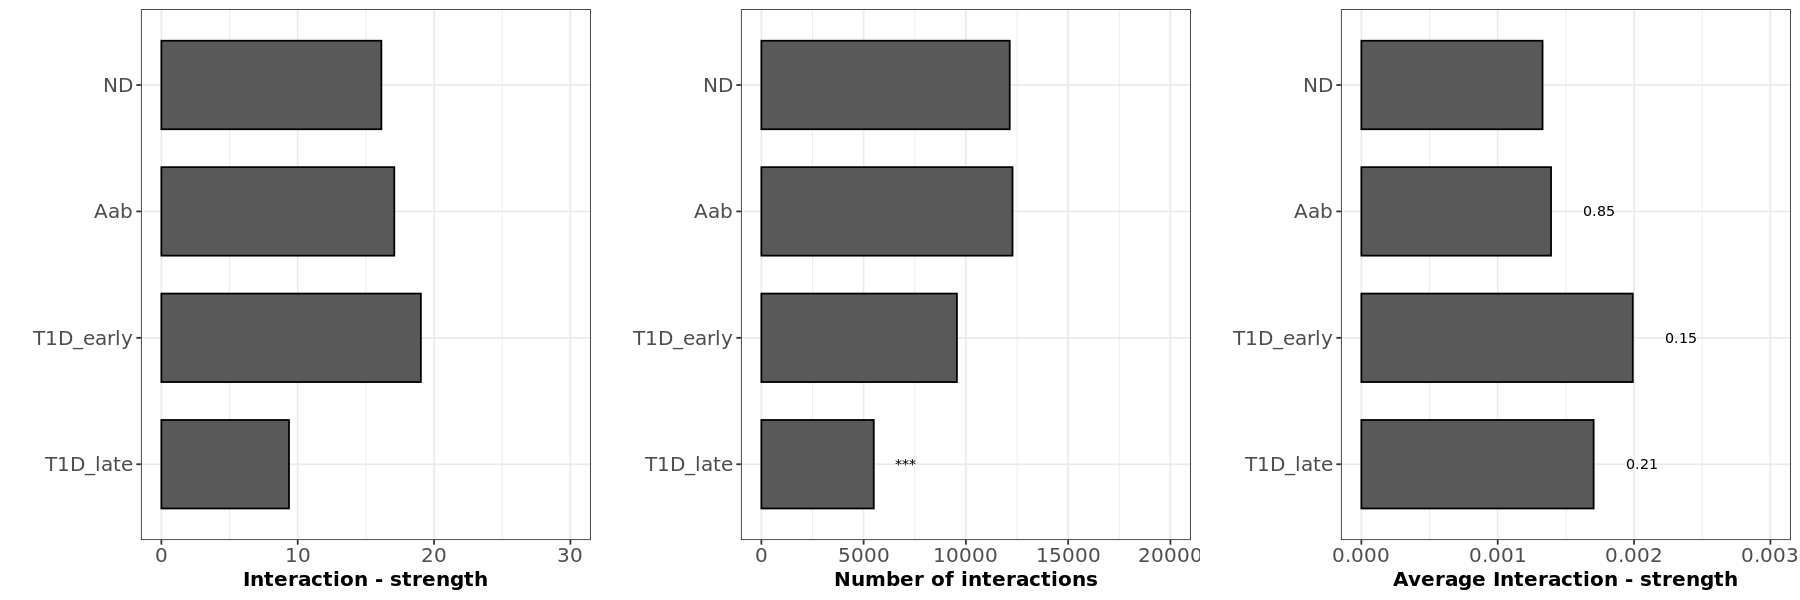

In [53]:
options(repr.plot.width=15, repr.plot.height=5)
grid.arrange(gg1, gg2, gg3, ncol = 3)

In [51]:
file.name = paste(permutations.test.res.dir, "Permutation.test_overall_changes.res", sep = "")
write.table(stat.data.plot, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 